In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, roc_auc_score, average_precision_score, balanced_accuracy_score, recall_score, f1_score, accuracy_score, precision_score

from ttc_bunching_pipeline import PipelineConfig
from ttc_bunching_pipeline.pipeline import build_training_data_bundle
from ttc_bunching_pipeline.modeling import (
    build_binary_tasks,
    default_task_threshold_policy,
    train_xgb_binary_tasks,
    
)

pd.set_option("display.max_columns", 300)
sns.set_theme(style="whitegrid")

In this notebook, we demonstrate the full model pipeline with a sample of possible risk-events that can be specified for the model pipeline. Please consult the README for more project context.

Risk-event binary classification tasks are predetermined. In this model, they will be of the form:

Given  ``` >= b ```  bunching incidents from a pair of streetcars in the last ```s```  stops, predict if there will be another ```>= n ```  bunching incidents from the same pair of streetcars in the next ```m``` stops.


You can specify a single risk-event type, or specify a collection of risk-event types. To specify a risk-event type, you must provide a 4-tuple of integers (b,s,n,m).


In [ ]:
def task_spec(b: int, s: int, n: int, m: int, name: str | None = None) -> dict:
        
    if name is None:
        name = f"cond{int(b)}of{int(s)}_to_next{int(m)}_ge{int(n)}_binary"
    return {"name": name, "b": int(b), "s": int(s), "n": int(n), "m": int(m)}

RISK_TASK_DEFINITIONS = [
    task_spec(1, 1, 1, 2, "observed1_next2_gap1_binary"),
    task_spec(2, 2, 1, 2, "observed2_next2_gap1_binary"),
    # task_spec(3,3,2,1),
    # task_spec(2,2,3,1),
    task_spec(3, 3, 1, 2, "observed3_next2_gap1_binary"),
    task_spec(3, 4, 2, 4, "cond3of4_to_next4_ge2_binary"),
    task_spec(3, 5, 2, 4, "cond3of5_to_next4_ge2_binary"),
    task_spec(1, 1, 1, 1, "observed1_next1_binary"),
]

For the provided risk-task definitions, a pipeline configuration object is formed -- to help with various model parameters associated to the risk-tasks. 

Each risk-task will have different feature and target dataframes, suitable for the particular risk-task definition at hand. Another utility of the pipeline configuration object is that we can hold many risk task definitions at a time, and define at once a bundle of feature / target dataframes suitable for a specified collection of risk-task definitions.

Note: ```incident_X```  consists of features only available within a specific time window. It only contains features relevant to a current stop, and lagged features. This is important to get right, so that there is no future data-leakage.


Think of it this way: in a deployment scenario, the transit command center will have all streetcar arrival data collected to the 
current point in time (up to a certain window of relevance: these models only use up to a single day of lagged information as features but are trained on data between 2024-2025). From this, the data is organized in bunching episodes and incidents. This then populates a dataframe ```incident_X``` consisting those bunching episodes that are involved with a <b> risk-pattern </b>, for a specified risk-event classification task. From ```incident_X``` the pre-trained model can attempt to make a prediction about the current state of bunching episodes and risk-patterns, and whether these risk-patterns will extend to a full risk-event. 

At the time of training, we have a notion of past, present and future events. The dataframe ```incident_df``` contains a full-view of all bunching episodes, the bunching episodes involved in risk-patterns and which of these risk-patterns extend to full risk-events. This is how we can calculate the true target ```y```, in order to train our prediction model and evaluate performance. Of course, at time of deployment, there will be no confusion about which piece of the dataframe should be considered as part of the "future", and which part of the dataframe should be considered to be part of the present and past. At time of deployment, the "future" part of the dataframe will simply not exist! Regardless, at time of deployment the ```incident_df``` dataframe consists of episodes relevant to date, and from this we can form the appropriate ```incident_X``` dataframe as the input vector for the prediction model.


In [3]:
cfg = PipelineConfig(risk_task_definitions=RISK_TASK_DEFINITIONS)

task_def_df = pd.DataFrame(cfg.risk_task_definitions)
print("Configured risk tasks (b,s,n,m):")
display(task_def_df)



### add_external flag is for including features from external factors or not (i.e. weather, traffic signals..etc)
bundle = build_training_data_bundle(cfg=cfg, add_external=True)


incident_df = bundle.incident_df
confirmed_df = bundle.confirmed_df
incident_X = bundle.feature_bundle.incident_X
confirmed_X = bundle.feature_bundle.confirmed_X
cat_feats = bundle.feature_bundle.cat_feats
feature_cols = bundle.feature_bundle.feature_cols

print("events:", len(bundle.events))
print("contacts:", len(bundle.contacts))
print("episodes:", len(bundle.episodes))
print("incident rows:", len(incident_df), "| confirmed rows:", len(confirmed_df))
print("n features:", len(feature_cols), "(numeric=", len(bundle.feature_bundle.base_num_feats), ", categorical=", len(cat_feats), ")")
print("")
print("External sources:")
for k, v in bundle.external_sources.items():
    print(f"- {k}: {v}")


Configured risk tasks (b,s,n,m):


,name,b,s,n,m
0,observed1_next2_gap1_binary,1,1,1,2
1,observed2_next2_gap1_binary,2,2,1,2
2,observed3_next2_gap1_binary,3,3,1,2
3,cond3of4_to_next4_ge2_binary,3,4,2,4
4,cond3of5_to_next4_ge2_binary,3,5,2,4
5,observed1_next1_binary,1,1,1,1


[load_raw_events] loading modern CSV: data_files\chunks\df2025_all.csv.part0001.csv
  loaded 190,012 events  (2025-01-01 to 2025-01-29)
[load_raw_events] loading modern CSV: data_files\chunks\df2025_all.csv.part0002.csv
  loaded 191,944 events  (2025-01-29 to 2025-02-27)
[load_raw_events] loading modern CSV: data_files\chunks\df2025_all.csv.part0003.csv
  loaded 189,071 events  (2025-02-27 to 2025-03-27)
[load_raw_events] loading modern CSV: data_files\chunks\df2025_all.csv.part0004.csv
  loaded 190,274 events  (2025-03-27 to 2025-04-22)
[load_raw_events] loading modern CSV: data_files\chunks\df2025_all.csv.part0005.csv
  loaded 191,216 events  (2025-04-22 to 2025-05-18)
[load_raw_events] loading modern CSV: data_files\chunks\df2025_all.csv.part0006.csv
  loaded 189,372 events  (2025-05-18 to 2025-06-13)
[load_raw_events] loading modern CSV: data_files\chunks\df2025_all.csv.part0007.csv
  loaded 190,381 events  (2025-06-13 to 2025-07-09)
[load_raw_events] loading modern CSV: data_files

In [4]:
task_specs = build_binary_tasks(incident_df=incident_df, incident_X=incident_X, cfg=cfg)
task_policy = default_task_threshold_policy()

print("task count:", len(task_specs))
print("tasks:")
for spec in task_specs:
    print("-", spec.task, "| rows=", len(spec.X))



## set tuning flag if the model should go through hyperparameter tuning 
metrics_xgb_df, xgb_models, xgb_predictions, xgb_cv_diagnostics = train_xgb_binary_tasks(
    task_specs=task_specs,
    cat_feats=cat_feats,
    cfg=cfg,
    task_threshold_policy = task_policy,
    tuning_flag= True
)

display(metrics_xgb_df.sort_values("ap_test", ascending=False).round(4))


task count: 6
tasks:
- observed1_next2_gap1_binary | rows= 50997
- observed2_next2_gap1_binary | rows= 20779
- observed3_next2_gap1_binary | rows= 12671
- cond3of4_to_next4_ge2_binary | rows= 12748
- cond3of5_to_next4_ge2_binary | rows= 12861
- observed1_next1_binary | rows= 50997


,task,type,cv_n_folds,cv_mean_ap,cv_std_ap,threshold_policy,threshold_selection_metric_oof_f2,threshold_selection_metric_oof_f1,threshold_selection_metric_oof_fpr,base_rate_test,ap_oof,ap_test,auc_test,f1_test,f2_test,precision_test,recall_test,accuracy_test,balanced_accuracy_test,best_threshold,best_cfg
5,observed3_next2_gap1_binary,binary_strict_timecv_xgboost,4,0.9383,0.0143,f2,0.7551,0.8091,0.3868,0.8755,0.9299,0.9459,0.7556,0.9386,0.9548,0.9128,0.9659,0.8894,0.6586,0.83,"{""max_depth"": 10, ""learning_rate"": 0.025869132..."
4,observed2_next2_gap1_binary,binary_strict_timecv_xgboost,4,0.9025,0.0187,f2,0.9605,0.9067,0.3831,0.6822,0.9044,0.9095,0.8616,0.9003,0.9576,0.8186,1.0000,0.8488,0.7622,0.07,"{""max_depth"": 8, ""learning_rate"": 0.0236011742..."
1,cond3of5_to_next4_ge2_binary,binary_strict_timecv_xgboost,4,0.8898,0.0256,f2,0.9363,0.8868,0.3920,0.6405,0.8924,0.8952,0.8781,0.8659,0.8819,0.8406,0.8929,0.8229,0.7956,0.46,"{""max_depth"": 7, ""learning_rate"": 0.1480038367..."
0,cond3of4_to_next4_ge2_binary,binary_strict_timecv_xgboost,4,0.8674,0.0316,f2,0.9141,0.8688,0.3983,0.6385,0.8545,0.8657,0.8417,0.8786,0.9213,0.8157,0.9521,0.8321,0.7861,0.52,"{""max_depth"": 9, ""learning_rate"": 0.0651019247..."
3,observed1_next2_gap1_binary,binary_strict_timecv_xgboost,4,0.8582,0.0178,f2,0.8890,0.8131,0.3962,0.5193,0.8551,0.8270,0.8459,0.8052,0.8845,0.7006,0.9466,0.7622,0.7547,0.35,"{""max_depth"": 10, ""learning_rate"": 0.022669381..."
2,observed1_next1_binary,binary_strict_timecv_xgboost,4,0.8060,0.0333,f2,0.8716,0.7362,0.4964,0.4326,0.8018,0.7648,0.8382,0.7419,0.8683,0.5970,0.9796,0.7051,0.7377,0.07,"{""max_depth"": 10, ""learning_rate"": 0.071287549..."


The above results and metric evaluations will vary depending on the threshold policy chosen. One can adjust the default policies
in modeling.py to arrive at different performance results, for specific metrics. For a given risk-task, one can specify a policy of the form ```{ 'name': name, 'fpr_cap': fpr_cap}```. Here, ```name``` is the metric to assess the threshold selection with, and ```fpr_cap``` is an upper limit to set on false positive rate, when assessing quality of threshold while doing the grid search. Of course, this is evaluated on validation sets, so model performance on the test set may exceed the false positive rate cap in final test evaluation. 


<b> Note to judges: </b> I apologize, previously I had a much messier working notebook, and I seem to have misplaced the particular set of hyperparameter 
settings and threshold tuning settings I used to produce some of the results in the data visualizations from the slides. However, I believe that these results above here are within the same ballpark, up to a few percentage points (in fact, risk-event of type (3,3,1,2) here I believe has better metrics than in the slides). I hope that that is satisfactory. Also note that I had a much larger sample of risk-event types when generating the charts for the slides (I had 14 different event types). It takes longer to train models for 14 event types, so in interest of time, I commented out a majority of them and only present 6 event types here. 

In [5]:
summary_cols = [
    "task",
    "base_rate_test",
    "ap_test",
    "auc_test",
    "f1_test",
    "f2_test",
    "precision_test",
    "recall_test",
    "balanced_accuracy_test",
    "best_threshold",
    "threshold_policy",
]

display(metrics_xgb_df[summary_cols].sort_values("task").round(4))



,task,base_rate_test,ap_test,auc_test,f1_test,f2_test,precision_test,recall_test,balanced_accuracy_test,best_threshold,threshold_policy
0,cond3of4_to_next4_ge2_binary,0.6385,0.8657,0.8417,0.8786,0.9213,0.8157,0.9521,0.7861,0.52,f2
1,cond3of5_to_next4_ge2_binary,0.6405,0.8952,0.8781,0.8659,0.8819,0.8406,0.8929,0.7956,0.46,f2
2,observed1_next1_binary,0.4326,0.7648,0.8382,0.7419,0.8683,0.5970,0.9796,0.7377,0.07,f2
3,observed1_next2_gap1_binary,0.5193,0.8270,0.8459,0.8052,0.8845,0.7006,0.9466,0.7547,0.35,f2
4,observed2_next2_gap1_binary,0.6822,0.9095,0.8616,0.9003,0.9576,0.8186,1.0000,0.7622,0.07,f2
5,observed3_next2_gap1_binary,0.8755,0.9459,0.7556,0.9386,0.9548,0.9128,0.9659,0.6586,0.83,f2


We can display relevant charts for binary classification tasks. 

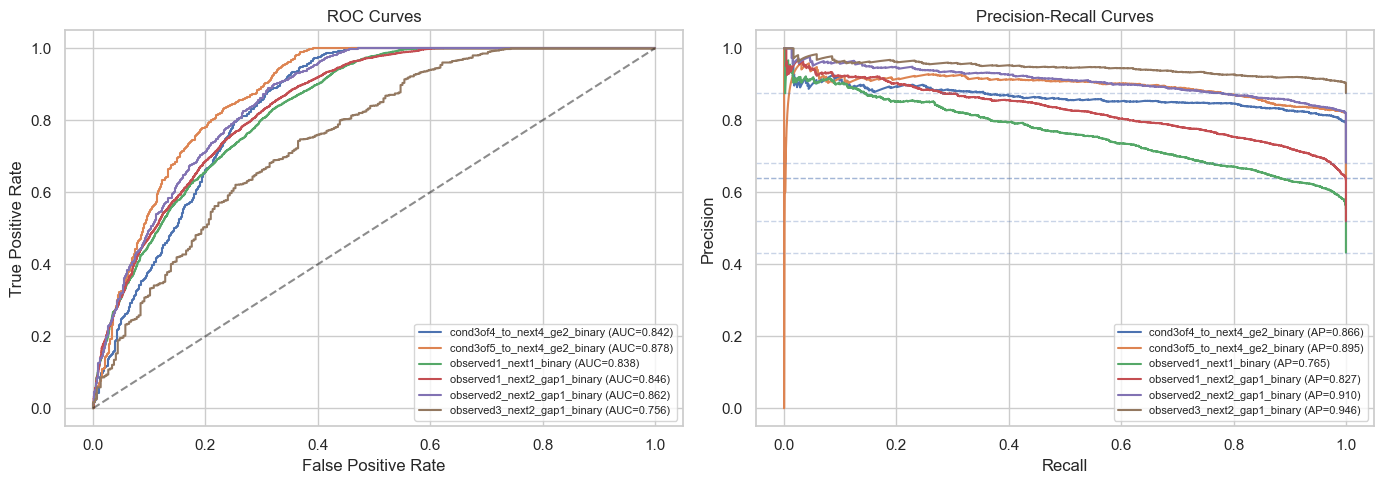

In [6]:
# ROC + PR curves
roc_rows = []
pr_rows = []
for task in metrics_xgb_df["task"].tolist():
    pred_df = xgb_predictions[task]
    y_true = pred_df["y_true"].to_numpy(dtype="int8")
    p_hat = pred_df["proba"].to_numpy(dtype="float64")

    fpr, tpr, _ = roc_curve(y_true, p_hat)
    prec, rec, _ = precision_recall_curve(y_true, p_hat)

    roc_rows.append((task, fpr, tpr, roc_auc_score(y_true, p_hat)))
    pr_rows.append((task, rec, prec, average_precision_score(y_true, p_hat), float(y_true.mean())))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for task, fpr, tpr, aucv in roc_rows:
    axes[0].plot(fpr, tpr, label=f"{task} (AUC={aucv:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_title("ROC Curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=8)

for task, rec, prec, apv, base_rate in pr_rows:
    axes[1].plot(rec, prec, label=f"{task} (AP={apv:.3f})")
    axes[1].axhline(base_rate, linestyle="--", linewidth=1, alpha=0.3)
axes[1].set_title("Precision-Recall Curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()



Displaying recall, precision and false positive rate metrics, we can inspect how our models are doing.

In [7]:

rows = []
for task in metrics_xgb_df["task"].tolist():
    pred_df = xgb_predictions[task]
    y_true = pred_df["y_true"].to_numpy(dtype="int8")
    y_pred = pred_df["pred"].to_numpy(dtype="int8")

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    rows.append(
        {
            "task": task,
            "n_test": int(len(y_true)),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "false_positive_rate": fp / max(fp + tn, 1),
            "recall": tp / max(tp + fn, 1),
            "precision": tp / max(tp + fp, 1),
        }
    )

task_prf_df = pd.DataFrame(rows).sort_values("task").reset_index(drop=True)

# optional: include the threshold used for each task
if "best_threshold" in metrics_xgb_df.columns:
    task_prf_df = task_prf_df.merge(
        metrics_xgb_df[["task", "best_threshold"]], on="task", how="left"
    )

display(
    task_prf_df.style.format(
        {
            "false_positive_rate": "{:.3f}",
            "recall": "{:.3f}",
            "precision": "{:.3f}",
            "best_threshold": "{:.3f}",
        }
    )
)

,task,n_test,tn,fp,fn,tp,false_positive_rate,recall,precision,best_threshold
0,cond3of4_to_next4_ge2_binary,2257,506,310,69,1372,0.380,0.952,0.816,0.520
1,cond3of5_to_next4_ge2_binary,2434,611,264,167,1392,0.302,0.893,0.841,0.460
2,observed1_next1_binary,9200,2588,2632,81,3899,0.504,0.980,0.597,0.070
3,observed1_next2_gap1_binary,9200,2489,1933,255,4523,0.437,0.947,0.701,0.350
4,observed2_next2_gap1_binary,3943,657,596,0,2690,0.476,1.000,0.819,0.070
5,observed3_next2_gap1_binary,2377,104,192,71,2010,0.649,0.966,0.913,0.830


We consider our metrics with two baselines. One baseline is "silly" and just takes all negative predictions. The other baseline is basically making a random choice of classification for a given task.

In [8]:
# Compare model vs baselines for each risk-event task

def safe_auc(y_true, p_hat):
    y_u = np.unique(y_true)
    if len(y_u) < 2:
        return np.nan
    return float(roc_auc_score(y_true, p_hat))

def fpr_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return float(fp / max(fp + tn, 1))

def metric_row(task, model_name, y_true, p_hat, y_pred):
    return {
        "task": task,
        "model": model_name,
        "n_test": int(len(y_true)),
        "base_rate_test": float(np.mean(y_true)),
        "alert_rate": float(np.mean(y_pred)),
        "ap": float(average_precision_score(y_true, p_hat)),
        "auc": safe_auc(y_true, p_hat),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "fpr": fpr_score(y_true, y_pred),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
    }

rng = np.random.default_rng(20260322)
N_RANDOM_RUNS = 200
rows = []

for task in metrics_xgb_df["task"].tolist():
    pred_df = xgb_predictions[task]
    y_true = pred_df["y_true"].to_numpy(dtype="int8")
    p_model = pred_df["proba"].to_numpy(dtype="float64")
    y_model = pred_df["pred"].to_numpy(dtype="int8")

    # Model
    rows.append(metric_row(task, "xgb_model", y_true, p_model, y_model))

    # Baseline 1: always negative
    p_zero = np.zeros_like(p_model, dtype="float64")
    y_zero = np.zeros_like(y_true, dtype="int8")
    rows.append(metric_row(task, "baseline_all_negative", y_true, p_zero, y_zero))

    # Baseline 2: random ranking with same alert rate as model (averaged over runs)
    k = int(y_model.sum())
    rand_rows = []
    for _ in range(N_RANDOM_RUNS):
        scores = rng.random(len(y_true))
        y_rand = np.zeros(len(y_true), dtype="int8")
        if k >= len(y_true):
            y_rand[:] = 1
        elif k > 0:
            cutoff_idx = np.argpartition(scores, len(y_true) - k)[len(y_true) - k :]
            y_rand[cutoff_idx] = 1
        rand_rows.append(metric_row(task, "baseline_random@same_alert_rate", y_true, scores, y_rand))

    rand_avg = pd.DataFrame(rand_rows).mean(numeric_only=True).to_dict()
    rand_avg.update({"task": task, "model": "baseline_random@same_alert_rate", "n_test": int(len(y_true))})
    rows.append(rand_avg)

compare_df = pd.DataFrame(rows).sort_values(["task", "model"]).reset_index(drop=True)
display(compare_df.round(4))

# Optional: model gains vs baselines
metric_cols = ["ap", "auc", "precision", "recall", "fpr", "f1", "accuracy", "balanced_accuracy"]
wide = compare_df.pivot(index="task", columns="model", values=metric_cols)

gain_vs_allneg = (
    wide.xs("xgb_model", level=1, axis=1) - wide.xs("baseline_all_negative", level=1, axis=1)
).add_prefix("gain_vs_allneg_")

gain_vs_rand = (
    wide.xs("xgb_model", level=1, axis=1) - wide.xs("baseline_random@same_alert_rate", level=1, axis=1)
).add_prefix("gain_vs_rand_")

gain_df = pd.concat([gain_vs_allneg, gain_vs_rand], axis=1).reset_index()
display(gain_df.round(4))


,task,model,n_test,base_rate_test,alert_rate,ap,auc,precision,recall,fpr,f1,accuracy,balanced_accuracy
0,cond3of4_to_next4_ge2_binary,baseline_all_negative,2257,0.6385,0.0000,0.6385,0.5000,0.0000,0.0000,0.0000,0.0000,0.3615,0.5000
1,cond3of4_to_next4_ge2_binary,baseline_random@same_alert_rate,2257,0.6385,0.7452,0.6409,0.5017,0.6389,0.7458,0.7443,0.6882,0.5686,0.5007
2,cond3of4_to_next4_ge2_binary,xgb_model,2257,0.6385,0.7452,0.8657,0.8417,0.8157,0.9521,0.3799,0.8786,0.8321,0.7861
3,cond3of5_to_next4_ge2_binary,baseline_all_negative,2434,0.6405,0.0000,0.6405,0.5000,0.0000,0.0000,0.0000,0.0000,0.3595,0.5000
4,cond3of5_to_next4_ge2_binary,baseline_random@same_alert_rate,2434,0.6405,0.6804,0.6405,0.4989,0.6405,0.6804,0.6803,0.6599,0.5507,0.5000
5,cond3of5_to_next4_ge2_binary,xgb_model,2434,0.6405,0.6804,0.8952,0.8781,0.8406,0.8929,0.3017,0.8659,0.8229,0.7956
6,observed1_next1_binary,baseline_all_negative,9200,0.4326,0.0000,0.4326,0.5000,0.0000,0.0000,0.0000,0.0000,0.5674,0.5000
7,observed1_next1_binary,baseline_random@same_alert_rate,9200,0.4326,0.7099,0.4330,0.4995,0.4324,0.7095,0.7102,0.5373,0.4714,0.4996
8,observed1_next1_binary,xgb_model,9200,0.4326,0.7099,0.7648,0.8382,0.5970,0.9796,0.5042,0.7419,0.7051,0.7377
9,observed1_next2_gap1_binary,baseline_all_negative,9200,0.5193,0.0000,0.5193,0.5000,0.0000,0.0000,0.0000,0.0000,0.4807,0.5000


,task,gain_vs_allneg_ap,gain_vs_allneg_auc,gain_vs_allneg_precision,gain_vs_allneg_recall,gain_vs_allneg_fpr,gain_vs_allneg_f1,gain_vs_allneg_accuracy,gain_vs_allneg_balanced_accuracy,gain_vs_rand_ap,gain_vs_rand_auc,gain_vs_rand_precision,gain_vs_rand_recall,gain_vs_rand_fpr,gain_vs_rand_f1,gain_vs_rand_accuracy,gain_vs_rand_balanced_accuracy
0,cond3of4_to_next4_ge2_binary,0.2272,0.3417,0.8157,0.9521,0.3799,0.8786,0.4705,0.2861,0.2248,0.3400,0.1768,0.2064,-0.3644,0.1904,0.2635,0.2854
1,cond3of5_to_next4_ge2_binary,0.2547,0.3781,0.8406,0.8929,0.3017,0.8659,0.4634,0.2956,0.2547,0.3792,0.2000,0.2125,-0.3786,0.2061,0.2722,0.2955
2,observed1_next1_binary,0.3322,0.3382,0.5970,0.9796,0.5042,0.7419,0.1377,0.2377,0.3318,0.3387,0.1646,0.2702,-0.2060,0.2046,0.2338,0.2381
3,observed1_next2_gap1_binary,0.3077,0.3459,0.7006,0.9466,0.4371,0.8052,0.2815,0.2547,0.3067,0.3455,0.1811,0.2447,-0.2644,0.2082,0.2542,0.2546
4,observed2_next2_gap1_binary,0.2273,0.3616,0.8186,1.0000,0.4757,0.9003,0.5311,0.2622,0.2275,0.3625,0.1363,0.1666,-0.3576,0.1499,0.2272,0.2621
5,observed3_next2_gap1_binary,0.0704,0.2556,0.9128,0.9659,0.6486,0.9386,0.7648,0.1586,0.0701,0.2558,0.0373,0.0395,-0.2778,0.0384,0.0692,0.1586


We consider our confusion matrices compared to the "silly" baselines.

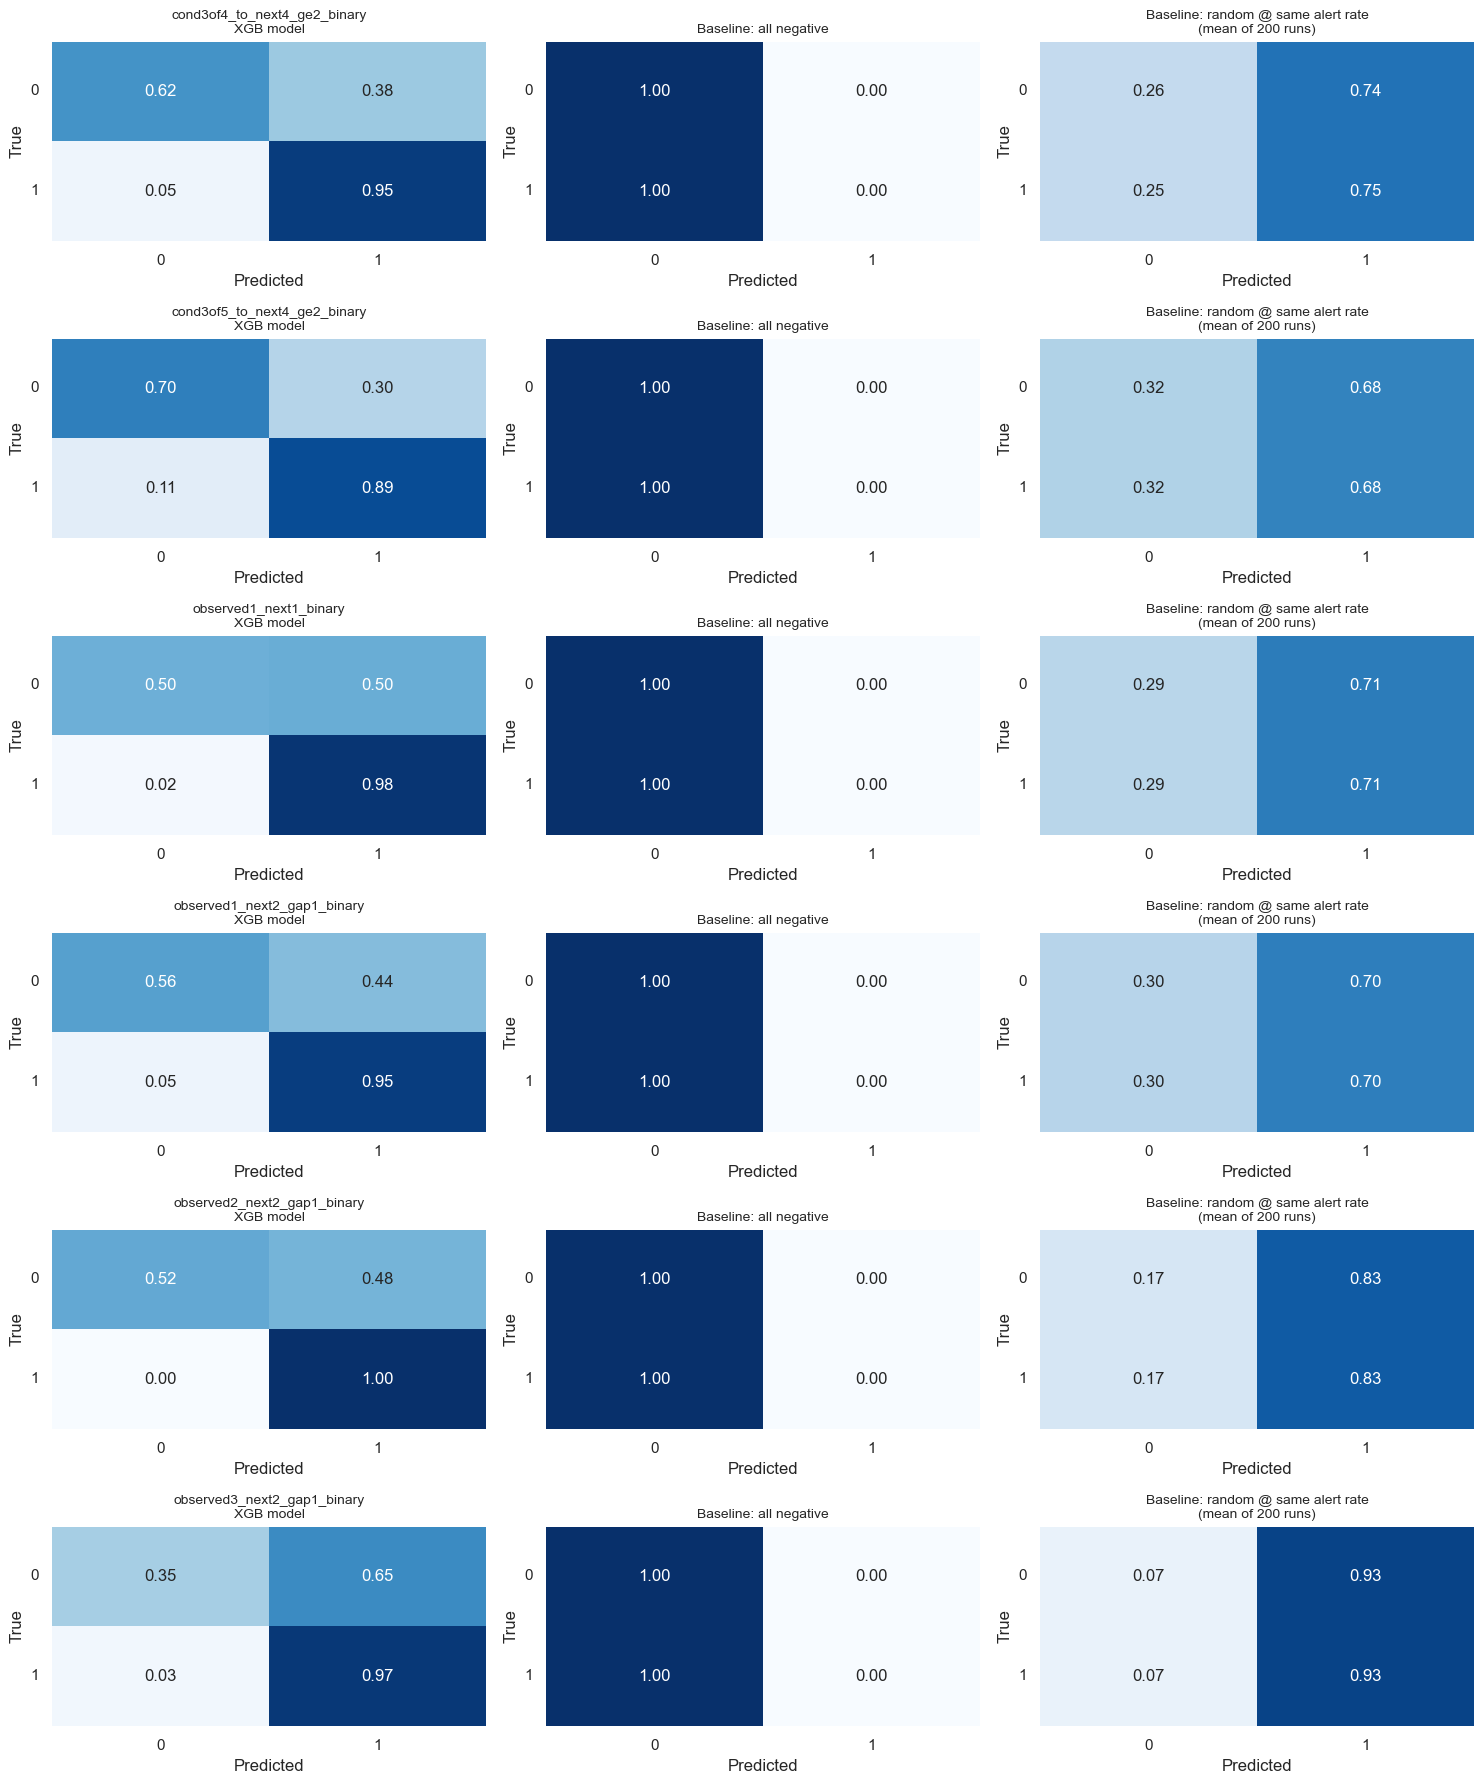

In [ ]:

tasks_to_plot = metrics_xgb_df["task"].tolist()

N_RANDOM_RUNS = 200
RNG_SEED = 20260322
rng = np.random.default_rng(RNG_SEED)

def row_normalize(cm: np.ndarray) -> np.ndarray:
    return cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

def random_preds_same_alert_rate(n: int, k_alerts: int, rng_obj) -> np.ndarray:
    y_rand = np.zeros(n, dtype="int8")
    if k_alerts <= 0:
        return y_rand
    if k_alerts >= n:
        y_rand[:] = 1
        return y_rand
    s = rng_obj.random(n)
    idx = np.argpartition(s, n - k_alerts)[n - k_alerts :]
    y_rand[idx] = 1
    return y_rand

n_tasks = len(tasks_to_plot)
fig, axes = plt.subplots(n_tasks, 3, figsize=(15, max(3, 3.0 * n_tasks)))
if n_tasks == 1:
    axes = np.array([axes])

for i, task in enumerate(tasks_to_plot):
    pred_df = xgb_predictions[task]
    y_true = pred_df["y_true"].to_numpy(dtype="int8")
    y_model = pred_df["pred"].to_numpy(dtype="int8")

    # Model CM
    cm_model = confusion_matrix(y_true, y_model, labels=[0, 1]).astype(float)

    # Baseline 1: always negative
    y_zero = np.zeros_like(y_true, dtype="int8")
    cm_zero = confusion_matrix(y_true, y_zero, labels=[0, 1]).astype(float)

    # Baseline 2: random, matched alert count to model (average CM across runs)
    k = int(y_model.sum())
    cm_rand_sum = np.zeros((2, 2), dtype=float)
    for _ in range(N_RANDOM_RUNS):
        y_rand = random_preds_same_alert_rate(len(y_true), k, rng)
        cm_rand_sum += confusion_matrix(y_true, y_rand, labels=[0, 1]).astype(float)
    cm_rand = cm_rand_sum / N_RANDOM_RUNS

    mats = [row_normalize(cm_model), row_normalize(cm_zero), row_normalize(cm_rand)]
    titles = [
        f"{task}\nXGB model",
        "Baseline: all negative",
        f"Baseline: random @ same alert rate\n(mean of {N_RANDOM_RUNS} runs)",
    ]

    for j, (cmn, ttl) in enumerate(zip(mats, titles)):
        ax = axes[i, j]
        sns.heatmap(
            cmn, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            cbar=False, ax=ax
        )
        ax.set_title(ttl, fontsize=10)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_xticklabels(["0", "1"])
        ax.set_yticklabels(["0", "1"], rotation=0)

plt.tight_layout()
plt.show()
